I began by importing all the packages necessary to complete the assignment. I created some column names for the agaricus-lepiota.csv file based on the agaricus-lepiota.names file. I split the data into my target and my features. "Class" is my target because it's what I'm trying to predict. The rest of the columns are my features because they'll be used to make predictions. After looking through the data, I noticed there were a number of missing values in the "stalk-root" column. In order to take care of this, I changed each "?" to "NaN". Then I imputed those missing values with the mean of the column. I split my data into training and test data. I put 20% of the data toward testing, and 80% toward training. I used one-hot encoder to encode my features into data that my model can interpret, and I used label-encoder to encode the target into data the model can interpret. I created the initial sequential model with 1 input and 1 output layer. I included 128 neurons in the input layer because this gave me the most accuracy. I used 'relu' activation for my input layer to help my model learn the complex patterns of my data. I used 'sigmoid' activation in my output layer becuase this is a binary classification task. I then configured the model for training. I used 'adam' as my optimizer and 'binary crossentropy' as my loss functions, becuase this is a binary classification task. I trained and fit my sequential model through 10 epochs with a batch size of 32. I printed the confusion matrix for this model, which shows that our model predicted 843 true positives, 0 false positives, 0 false negatives, and 782 true negatives. This show that our model accuracy is good. Next, I used PCA to reduce the dimensions of my data and create a simpler and faster model. I used the same activation in this model that I did in my original sequential model. I also used the same optimizer and loss functions to configure my model. This model was a bit quicker, but gave me the same results according the the confusion matrix produced for the PCA model. 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


In [2]:
#create column namnes for the data based on agaricus-lepiota.names
column_headers = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]


In [3]:
#load the dataset
mushroom_data = pd.read_csv('Final_project/data/agaricus-lepiota.csv', header=None, names=column_headers)
mushroom_data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [4]:
#separate the features from the target. x is the features, y is the target. 
X = mushroom_data.drop('class', axis=1)
y = mushroom_data['class']

In [5]:
#There are some missing values in the stalk-root columns. I replaced '?' with NaN first and then
#imputed the missing values with a mode.
X.replace('?', np.nan, inplace=True)
X['stalk-root'].fillna(X['stalk-root'].mode()[0], inplace=True)

In [6]:
#split the data into training and test sets. 80% of the data is set for training and 20% is set for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
#Use one-hot encoder to encode the features.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [8]:
#Use label encode to encde the targets.
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [9]:
#Create and train the imitial Sequential model.
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_encoded.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

2025-12-10 17:37:55.880266: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               14976     
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 15,105
Trainable params: 15,105
Non-trainable params: 0
_________________________________________________________________


In [11]:
print("Training initial neural network:")
%time history = model.fit(X_train_encoded, y_train_encoded, epochs=10, batch_size=32, verbose=0)


Training initial neural network:
CPU times: user 3.3 s, sys: 514 ms, total: 3.81 s
Wall time: 3.23 s


51/51 [==============================] - 0s 1ms/step


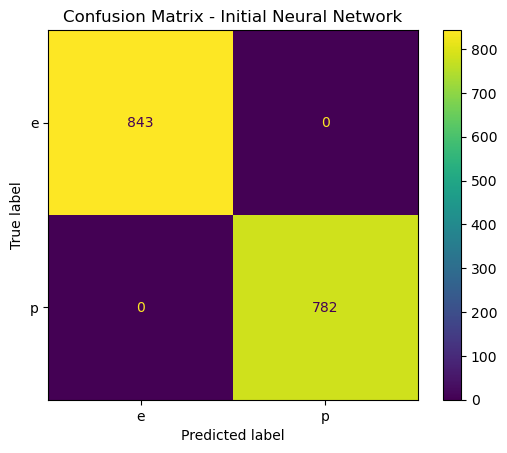

In [12]:
#Evaluate the initial sequential model amd print the confusion matrix
y_pred_probs = model.predict(X_test_encoded)
y_pred = (y_pred_probs > 0.5).astype(int)
cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title('Confusion Matrix - Initial Neural Network')
plt.show()

In [13]:
#Use PCA to perform dimensionality reduction
pca = PCA(n_components=0.95) 
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

In [14]:
#Create and train a new neural network on the PCAed data.
model_pca = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dense(1, activation='sigmoid')
    ])

model_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [15]:
model_pca.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 128)               5248      
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 5,377
Trainable params: 5,377
Non-trainable params: 0
_________________________________________________________________


In [16]:

print("\nTraining neural network with PCA-reduced data:")
%time history_pca = model_pca.fit(X_train_pca, y_train_encoded, epochs=10, batch_size=32, verbose=0)


Training neural network with PCA-reduced data:
CPU times: user 3.15 s, sys: 475 ms, total: 3.62 s
Wall time: 2.64 s


51/51 [==============================] - 0s 1ms/step


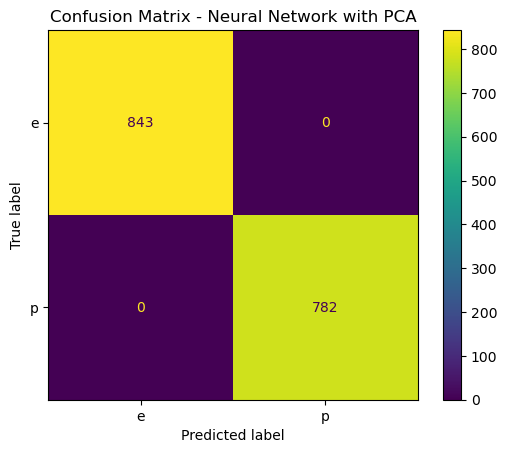

In [17]:
#Evaluate the new model and display the confusion matrix
y_pred_probs_pca = model_pca.predict(X_test_pca)
y_pred_pca = (y_pred_probs_pca > 0.5).astype(int)
cm_pca = confusion_matrix(y_test_encoded, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=label_encoder.classes_)
disp_pca.plot()
plt.title('Confusion Matrix - Neural Network with PCA')
plt.show()

In [18]:
model.save('model_pca.h5')

CONCEPT QUESTIONS

a. Before one-hot encoding, the data has 22 features. One-hot encoding turns each category within a feature into a new feature, leaving us with 148 features.

b. The unit parameters of the output layer in the neaural netweork should be 1. This is because it's a binary classification task, with the two options being edible and poisonous.

c. The neural network contains 257 connections.

d. PCA reduces the components 40. This is about 27% of the encoded components, but keep 95% of variance.

e. The input_dim parameter of the first layer needs to change because the input data's dimensionality has changed. The first neural network was trained with on-hot encoder, which had a higher number if features. The second network was trained with PCA, leaving less features.

f. The training time of the PCA neural network is a bit shorter than the training time of the sequential neural network. This is what I'd expect because the PCA network has less features. 